<a href="https://colab.research.google.com/github/morenakukurin/Repo_AIbio/blob/4.-vela/classification_vjezba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Logistic regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/classification_data.csv',
                      index_col=0)
dataset

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
Sample code number,,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1,2
1002945,5,4,4,5,7,10,3,2,1,2
1015425,3,1,1,1,2,2,3,1,1,2
1016277,6,8,8,1,3,4,3,7,1,2
1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2,1,1,1,2
841769,2,1,1,1,2,1,1,1,1,2
888820,5,10,10,3,7,3,8,10,2,4


In [5]:
dataset.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


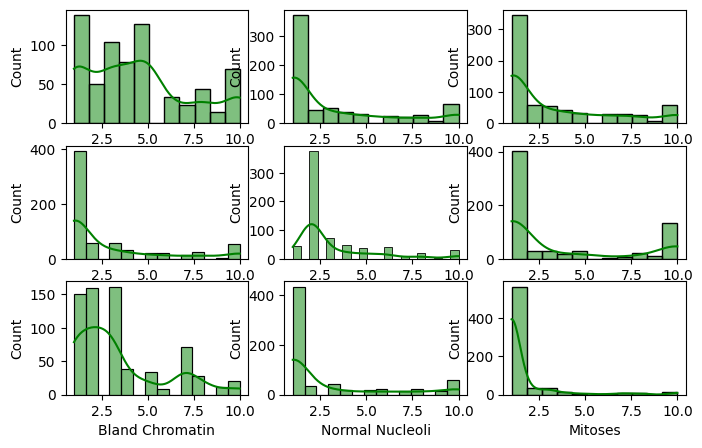

In [12]:
lista_features = dataset.iloc[:,:-1].columns.to_list()
fig, axes = plt.subplots(3,3, figsize = (8,5))
axes = axes.flatten()
lista_features
for i,column in enumerate(lista_features):
  sns.histplot(dataset[column], kde =True, ax = axes[i], color = 'green')

In [14]:
dataset.groupby('Class').describe().T

Class                           2           4
Clump Thickness count  444.000000  239.000000
                mean     2.963964    7.188285
                std      1.672661    2.437907
                min      1.000000    1.000000
                25%      1.000000    5.000000
...                           ...         ...
Mitoses         min      1.000000    1.000000
                25%      1.000000    1.000000
                50%      1.000000    1.000000
                75%      1.000000    3.000000
                max      8.000000   10.000000

[72 rows x 2 columns]

In [15]:
!pip install pingouin
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.2 MB/s eta 0:00:00


In [18]:
class2 = dataset[dataset['Class']==2]
class4 = dataset[dataset.Class==4]

In [20]:
class2_mitoses = class2.Mitoses
class4_mitoses = dataset[dataset.Class==4]['Mitoses']

In [21]:
pg.mwu(class2_mitoses,class4_mitoses)

,U-val,alternative,p-val,RBC,CLES
MWU,30599.0,two-sided,3.743169e-43,-0.423291,0.288354


explore the data

In [23]:
dataset['Class'].value_counts()

,count
Class,
2,444
4,239


In [24]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
X.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
Sample code number,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1
1002945,5,4,4,5,7,10,3,2,1
1015425,3,1,1,1,2,2,3,1,1
1016277,6,8,8,1,3,4,3,7,1
1017023,4,1,1,3,2,1,3,1,1


#splitanje

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
X_train.shape, X_test.shape

((512, 9), (171, 9))

#skaliranje

In [26]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [27]:
pd.DataFrame(X_test, columns = X.columns).describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000
mean,0.026131,0.026122,0.042796,0.033094,0.003257,0.092511,-0.022284,-0.079507,0.058506
std,1.024764,1.019792,1.047723,1.035643,0.942086,1.029026,0.934030,0.918488,1.043453
min,-1.221435,-0.698690,-0.739615,-0.636429,-0.990024,-0.680844,-0.987748,-0.620700,-0.337439
25%,-0.864690,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439
50%,-0.151199,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.184369,-0.620700,-0.337439
75%,0.562292,0.612875,0.615244,0.244251,0.340402,1.255780,0.619010,0.021966,-0.337439
max,1.989274,2.252330,2.308817,2.534018,3.001253,1.809101,2.627457,2.271296,4.915666


In [28]:
#bitno je trenirati model na skaliranim x test podacima

#model class

In [29]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, penalty="elasticnet",
                                solver="saga", l1_ratio=0.9)
#fittamo na skaliranim x_train podacima
classifier.fit(X_train, y_train) #parametrizira odnos dijagnoze spram ovih featurea koje smo izmjerili

LogisticRegression(l1_ratio=0.9, penalty='elasticnet', random_state=0,
                   solver='saga')

In [30]:
pd.DataFrame(X_train, columns=X.columns)

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
0,0.919037,0.940766,2.308817,0.772659,-0.103073,1.809101,2.225768,2.271296,0.246239
1,1.275783,-0.042908,1.631388,0.068115,0.340402,1.532440,1.824078,1.949963,3.748309
2,1.275783,2.252330,2.308817,2.534018,1.227352,1.809101,2.627457,2.271296,-0.337439
3,-1.221435,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.987748,-0.620700,-0.337439
4,-1.221435,-0.698690,-0.062186,-0.636429,-0.990024,-0.680844,-0.586059,-0.620700,-0.337439
...,...,...,...,...,...,...,...,...,...
507,-0.151199,-0.370799,-0.739615,-0.636429,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439
508,0.205547,-0.698690,-0.739615,-0.284157,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439
509,-1.221435,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.987748,-0.620700,-0.337439
510,-0.507944,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439


In [32]:
pd.Series(np.squeeze(classifier.coef_), index = X.columns,
          name = 'classifier coef')

,classifier coef
Clump Thickness,1.083546
Uniformity of Cell Size,0.373845
Uniformity of Cell Shape,0.716528
Marginal Adhesion,0.516580
Single Epithelial Cell Size,0.539468
Bare Nuclei,1.504719
Bland Chromatin,0.754180
Normal Nucleoli,0.681137
Mitoses,0.210557


<Axes: >

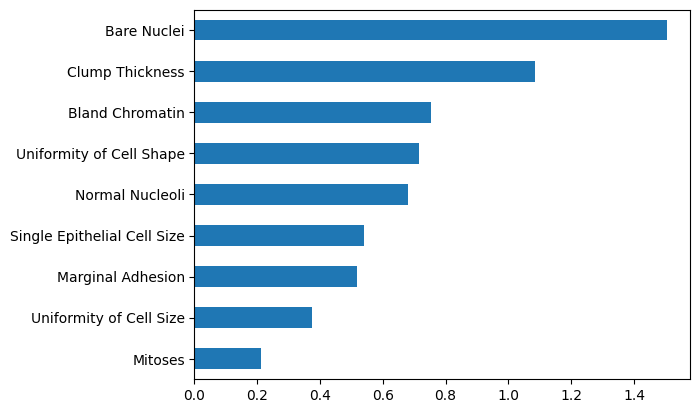

In [34]:
pd.Series(np.squeeze(classifier.coef_),
          name="coefs",
          index=X.columns).sort_values().plot.barh()

In [41]:
y_pred = classifier.predict(X_test)
y_pred = pd.Series(y_pred, name = 'y pred', index=y_test.index)
y_test

,Class
Sample code number,
1173347,2
1156017,2
706426,4
1330439,4
693702,2
...,...
1266124,2
1197979,2
764974,2


In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [42]:
result = pd.concat([y_test, y_pred], axis = 1)
result

,Class,y pred
Sample code number,,
1173347,2,2
1156017,2,2
706426,4,4
1330439,4,4
693702,2,2
...,...,...
1266124,2,2
1197979,2,2
764974,2,2


In [46]:
cm = confusion_matrix(y_test, y_pred, labels=[2, 4])
print(cm)

[[103   4]
 [  5  59]]


In [45]:
confusion_matrix

<function sklearn.metrics._classification.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)>

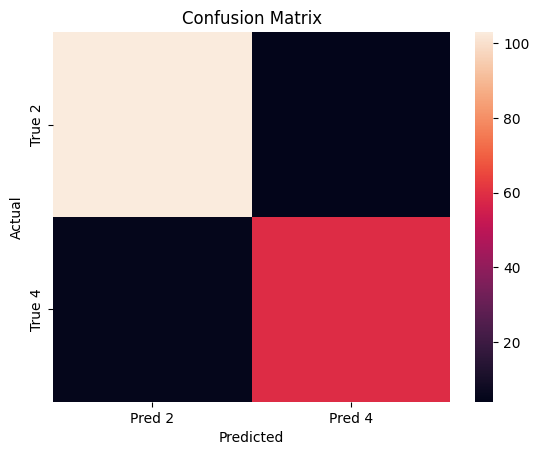

In [51]:
sns.heatmap(cm,
            xticklabels=["Pred 2", "Pred 4"],
            yticklabels=["True 2", "True 4"],
            )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [52]:
accuracy_score(y_test, y_pred)*100


94.73684210526315

In [59]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=4)
recall = recall_score(y_test, y_pred, pos_label=4)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

tn, fp, fn, tp

(np.int64(103), np.int64(4), np.int64(5), np.int64(59))

ACCURACY = TOČNE PREIDKICIJE/UKUPNI BROJ PREDIKCIJA
RECALL = TP/(TP+FN) ---> KOLIKI UDIO ZAISTA POZITIVNIH JE PREPOZNAO
PRECISION = TP/(TP+FP) ---> MJERI TOČNOST POZITIVNIH PREDIKCIJA
SPECIFICITY = TN/(TN+FP) ---> KOLIKI UDIO ZAISTA NEGATIVNIH JE PREPOZNAO